# PTM for OpenMMD - File Input

In [22]:
# Load files
LIGsdf = "/home/cwagner/openmmdl_ptm/OpenMMDL/openmmdl_ptm/maleimide.sdf"
PROTLIGpdb = "/home/cwagner/openmmdl_ptm/OpenMMDL/openmmdl_ptm/3ip9_dye.pdb"

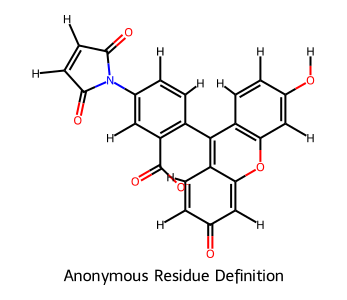

In [42]:
# Read Ligand from sdf
from openff.pablo import ResidueDefinition

LIGresdef = ResidueDefinition.anon_from_sdf(LIGsdf)
LIGresdef.visualize()

In [43]:
# Get Ligand Smarts
from rdkit import Chem

mol = Chem.SDMolSupplier(LIGsdf)

LIGsmiles = Chem.MolToSmiles(mol[0])
# SMILES als SMARTS-Pattern verwenden (exakter Match)
LIGsmarts = Chem.MolToSmarts(mol[0])
print(LIGsmiles, '->', LIGsmarts)

O=C([O-])c1cc(N2C(=O)C=CC2=O)ccc1-c1c2ccc(=O)cc-2oc2cc(O)ccc12 -> [#6]1=[#6]-[#6](=[#8])-[#7](-[#6]2:[#6]:[#6]:[#6](-[#6]3:[#6]4:[#6]:[#6]:[#6](=[#8]):[#6]:[#6]-4:[#8]:[#6]4:[#6]:[#6](-[#8]):[#6]:[#6]:[#6]:3:4):[#6](-[#6](=[#8])-[#8-]):[#6]:2)-[#6]-1=[#8]


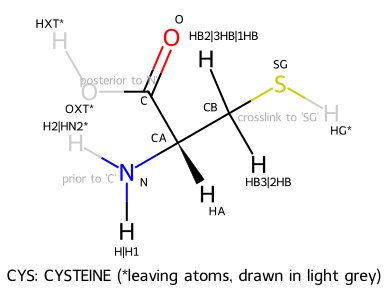

In [44]:
# Read Residue from PROTLIG.pdb
# Später automatisch aus .pdb auslesen
# Jetzt placeholder - Cys vordefiniert

from openff.pablo import STD_CCD_CACHE

RESname = "CYS"

RESresdef = STD_CCD_CACHE[RESname][0]
RESresdef.visualize()

In [45]:
# Get Residue Smarts
# From the CCD cache

from rdkit import Chem

RESmol = RESresdef.to_openff_molecule()
RESsmiles = RESmol.to_smiles()
RESrdmol = RESmol.to_rdkit()
RESsmarts = Chem.MolToSmarts(RESrdmol)
print(RESsmiles, '->', RESsmarts)


[H][O][C](=[O])[C@@]([H])([N]([H])[H])[C]([H])([H])[S][H] -> [#7](-[#6@](-[#6](=[#8])-[#8]-[H])(-[#6](-[#16]-[H])(-[H])-[H])-[H])(-[H])-[H]


In [46]:
# Get PTM Smarts
# muss aus PROTLIG.pdb gelesen werden
# wir haben die LIGsmiles und LIGsmarts optional zum durchsuchen der .pdb
# vorerst muss der Name der PTM Residue angegeben werden
# Bindungsordnungen werden durch ProLif erzeugt https://github.com/chemosim-lab/ProLIF

PTMname = "DYE"


PROTLIGmol = Chem.MolFromPDBFile(PROTLIGpdb, removeHs=False, sanitize=False)
PROTLIGfrags = Chem.SplitMolByPDBResidues(PROTLIGmol)  # dict: resname -> Fragment-Mol

for resname in PROTLIGfrags.keys():
    frag = PROTLIGfrags[resname]
    if resname != PTMname:
        continue
    PTMsmiles = Chem.MolToSmiles(frag)
    PTMsmarts = Chem.MolToSmarts(frag)
    print(PTMsmiles, '->', PTMsmarts)




[H]N[C@]([H])(CO)C([H])([H])S[C@]1([H])[C@H](O)N(C2C([H])C([H])C([C@H]3C4C([H])C([H])C(O)C([H])C4OC4C([H])C(O[H])C([H])C([H])C43)C(C(O)O)C2[H])[C@@H](O)C1([H])[H] -> [#7](-[#6@](-[#6]-[#8])(-[#6@](-[#16]-[#6@]1(-[#6@@](-[#6@@](-[#7](-[#6]2-[#6](-[#6](-[#6](-[#6](-[#6]-2-[H])-[#6](-[#8])-[#8])-[#6@@]2-[#6]3-[#6](-[#6](-[#6](-[#8]-[H])-[#6](-[#6]-3-[#8]-[#6]3-[#6](-[#6](-[#8])-[#6](-[#6](-[#6]-2-3)-[H])-[H])-[H])-[H])-[H])-[H])-[H])-[H])-[#6@]-1-[#8])-[#8])(-[H])-[H])-[H])(-[H])-[H])-[H])-[H]


In [65]:
import prolif as plf
from prolif.io import MoleculeStandardizer
from rdkit import Chem

mol = Chem.MolFromSmiles(PTMsmiles)
mol = Chem.RemoveHs(mol)  # collapse explicit H atoms back to implicit
lig_template = ("LIG", mol)

standardizer = MoleculeStandardizer(templates=[lig_template])
system_mol_std = standardizer(system_mol)

ligand_mol, protein_mol = plf.split_molecule(
    system_mol_std, lambda resid: resid.name == "LIG"
)
plf.display_residues(ligand_mol)

/tmp/ipykernel_1989687/693005775.py:12: UserWarning: Residue TYR38.A has a different number of heavy atoms than the standard residue. This may affect H-bond detection.
  system_mol_std = standardizer(system_mol)
/tmp/ipykernel_1989687/693005775.py:12: UserWarning: Residue LYS249.A has a different number of heavy atoms than the standard residue. This may affect H-bond detection.
  system_mol_std = standardizer(system_mol)
/tmp/ipykernel_1989687/693005775.py:12: UserWarning: Residue LEU298.B has a different number of heavy atoms than the standard residue. This may affect H-bond detection.
  system_mol_std = standardizer(system_mol)
/tmp/ipykernel_1989687/693005775.py:12: UserWarning: Residue LYS387.B has a different number of heavy atoms than the standard residue. This may affect H-bond detection.
  system_mol_std = standardizer(system_mol)
/tmp/ipykernel_1989687/693005775.py:12: UserWarning: Residue LIG1.G has a different number of heavy atoms than the standard residue. This may affect 

ValueError: Could not apply template for residue LIG1.G: No matching found

In [49]:
# Doppelbindungen in 

N[C@H](CO)CS[C@H](CO)CCO.O.O=C1C=CC(=O)N1c1ccc(-c2c3ccc(=O)cc-3oc3cc(O)ccc23)c(C(=O)([O-])O)c1


In [34]:
# Map LIGsmarts and RESsmarts to PTMsmarts bzw. LIGsmiles and RESsmiles to PTMsmiles
# 1) Automatische Reaction-Mapper (nur für bekannte organische Reaktionen) https://github.com/rxn4chemistry/rxnmapper

import pkg_resources
from rxnmapper import RXNMapper
rxn_mapper = RXNMapper()
rxns = [f"{LIGsmiles}.{RESsmiles}>>{PTMsmiles}"]
RXNsmiles = rxn_mapper.get_attention_guided_atom_maps(rxns)
print(RXNsmiles)

def split_smarts(smarts: str):
    reactants, products = smarts.split('>>')
    reactant_smarts = reactants.split('.')
    product_smarts = products.split('.')
    return reactant_smarts, product_smarts

reactant_smiles, product_smiles = split_smarts(RXNsmiles[0]["mapped_rxn"])
# print(reactant_smiles)
# print(product_smiles)

LIGsmiles = reactant_smiles[0]
RESsmiles = reactant_smiles[1]
PTMsmiles = product_smiles[0]

print(LIGsmiles)
print(RESsmiles)
print(PTMsmiles)


[{'confidence': 0.3109034623480817, 'mapped_rxn': 'O=[C:3]([C@@H:2]([NH2:1])[CH2:5][SH:6])[OH:4].[CH:7]1=[CH:8][C:9](=[O:10])[N:11]([c:12]2[cH:13][cH:14][c:15](-[c:16]3[c:17]4[cH:18][cH:19][c:20](=[O:21])[cH:22][c:23]-4[o:24][c:25]4[cH:26][c:27]([OH:28])[cH:29][cH:30][c:31]34)[c:32]([C:33](=[O:34])[O-:35])[cH:36]2)[C:37]1=[O:38]>>[NH2:1][C@H:2]([CH2:3][OH:4])[CH2:5][S:6][C@H:7]1[CH2:8][C@H:9]([OH:10])[N:11]([CH:12]2[CH2:13][CH2:14][CH:15]([CH:16]3[CH:17]4[CH2:18][CH2:19][CH:20]([OH:21])[CH2:22][CH:23]4[O:24][CH:25]4[CH2:26][CH:27]([OH:28])[CH2:29][CH2:30][CH:31]34)[CH:32]([CH:33]([OH:34])[OH:35])[CH2:36]2)[C@H:37]1[OH:38]'}]
O=[C:3]([C@@H:2]([NH2:1])[CH2:5][SH:6])[OH:4]
[CH:7]1=[CH:8][C:9](=[O:10])[N:11]([c:12]2[cH:13][cH:14][c:15](-[c:16]3[c:17]4[cH:18][cH:19][c:20](=[O:21])[cH:22][c:23]-4[o:24][c:25]4[cH:26][c:27]([OH:28])[cH:29][cH:30][c:31]34)[c:32]([C:33](=[O:34])[O-:35])[cH:36]2)[C:37]1=[O:38]
[NH2:1][C@H:2]([CH2:3][OH:4])[CH2:5][S:6][C@H:7]1[CH2:8][C@H:9]([OH:10])[N:11]([CH:12]2

In [33]:
# Define new PTM Residue
PTMresdef = ResidueDefinition.react(
    reactants=[RESresdef, LIGresdef],
    reactant_smarts = [
        RESsmiles,
        LIGsmiles,
    ],
    product_smarts = [
        PTMsmiles,
    ],
)[0][0] # Returns a list of tuples, we want the first (and only) element of any (identical) tuple
PTMresdef.visualize()

AssertionError: 

In [ ]:
help(ResidueDefinition)

Help on class ResidueDefinition in module openff.pablo.residue:

class ResidueDefinition(builtins.object)
 |  ResidueDefinition(residue_name: str | None, description: str, linking_bond: openff.pablo.residue.BondDefinition | None, crosslink: openff.pablo.residue.BondDefinition | None, atoms: tuple[openff.pablo.residue.AtomDefinition, ...], bonds: tuple[openff.pablo.residue.BondDefinition, ...], virtual_sites: tuple[str, ...]) -> None
 |
 |  Description of a residue from the Chemical Component Dictionary (CCD).
 |
 |  Methods defined here:
 |
 |  __delattr__(self, name)
 |      Implement delattr(self, name).
 |
 |  __eq__(self, other)
 |      Return self==value.
 |
 |  __hash__(self)
 |      Return hash(self).
 |
 |  __init__(self, residue_name: str | None, description: str, linking_bond: openff.pablo.residue.BondDefinition | None, crosslink: openff.pablo.residue.BondDefinition | None, atoms: tuple[openff.pablo.residue.AtomDefinition, ...], bonds: tuple[openff.pablo.residue.BondDefinitio

In [ ]:
help(Chem.MolToSmiles)

Help on built-in function MolToSmiles in module rdkit.Chem.rdmolfiles:

MolToSmiles(...)
    MolToSmiles( (rdkit.Chem.rdchem.Mol)mol, (SmilesWriteParams)params) -> str :
        Returns the canonical SMILES string for a molecule

        C++ signature :
            std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> > MolToSmiles(RDKit::ROMol,RDKit::SmilesWriteParams)

    MolToSmiles( (rdkit.Chem.rdchem.Mol)mol [, (bool)isomericSmiles=True [, (bool)kekuleSmiles=False [, (int)rootedAtAtom=-1 [, (bool)canonical=True [, (bool)allBondsExplicit=False [, (bool)allHsExplicit=False [, (bool)doRandom=False [, (bool)ignoreAtomMapNumbers=False]]]]]]]]) -> str :
        Returns the canonical SMILES string for a molecule
          ARGUMENTS:

            - mol: the molecule
            - isomericSmiles: (optional) include information about stereochemistry in
              the SMILES.  Defaults to true.
            - kekuleSmiles: (optional) use the Kekule form (no aromati

In [ ]:
help(STD_CCD_CACHE)

Help on CcdCache in module openff.pablo.ccd._ccdcache object:

class CcdCache(collections.abc.Mapping)
 |  CcdCache(library_paths: collections.abc.Iterable[pathlib.Path | str], cache_path: pathlib.Path | str | None = None, preload: list[str] = [], patches: collections.abc.Iterable[collections.abc.Mapping[str, collections.abc.Callable[[openff.pablo.residue.ResidueDefinition], list[openff.pablo.residue.ResidueDefinition]]]] = {}, extra_definitions: collections.abc.Mapping[str, collections.abc.Iterable[openff.pablo.residue.ResidueDefinition]] = {}, auto_download: bool = False)
 |
 |  Caches, patches, and presents the CCD as a Python ``Mapping``.
 |
 |  This class is a wrapper around a ``dict`` that stores residue definitions.
 |  When a residue is requested via the indexing syntax (for example,
 |  ``my_ccd_cache["ALA"]``), this dictionary is checked first. If the residue
 |  is not present and the ``auto_download`` attribute is truthy, the CCD is
 |  then checked. If the residue cannot b